In [16]:
import networkx as nx
from freyrelab.nets.paths2 import ShortestPaths

    why shortest_paths for node 0 returns paths with no 0 in it?

In [25]:
# G = nx.erdos_renyi_graph(10, 0.1)
G = nx.Graph()
G.add_nodes_from(range(10))
G.add_edges_from([(2, 4), (2, 6), (2, 5), (3, 9)])

shortest_paths = ShortestPaths(G)
shortest_paths.shortest_paths(3)

((3, 9),)

In [26]:
list(nx.all_pairs_shortest_path(G))

[(0, {0: [0]}),
 (1, {1: [1]}),
 (2, {2: [2], 4: [2, 4], 6: [2, 6], 5: [2, 5]}),
 (3, {3: [3], 9: [3, 9]}),
 (4, {4: [4], 2: [4, 2], 6: [4, 2, 6], 5: [4, 2, 5]}),
 (5, {5: [5], 2: [5, 2], 4: [5, 2, 4], 6: [5, 2, 6]}),
 (6, {6: [6], 2: [6, 2], 4: [6, 2, 4], 5: [6, 2, 5]}),
 (7, {7: [7]}),
 (8, {8: [8]}),
 (9, {9: [9], 3: [9, 3]})]

    betweenness_centrality sólo funciona para redes no dirigidas?
        sí

In [283]:
import numpy as np

In [288]:
for i in range(1,10):
    
    G = nx.erdos_renyi_graph(i, 1/i)

    shortest_paths = ShortestPaths(G)
    jf = shortest_paths.betweenness()


    nfoo = nx.betweenness_centrality(G, normalized=False).values()

    jf = np.asarray(sorted(list(jf)))
    nfoo = np.asarray(sorted(list(nfoo)))

    try:
        assert np.allclose(jf, nfoo), f"i: {i}, jf: {jf}, nfoo: {nfoo}"
    except ValueError as e:
        print(e)
        e_jf, e_nfoo = jf, nfoo
        print(f"i: {i}, jf: {jf}, nfoo: {nfoo}")

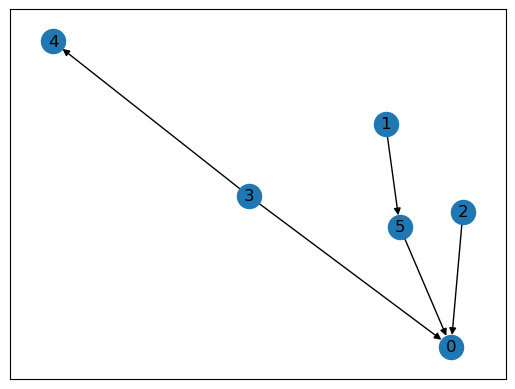

In [249]:
nx.draw_networkx(g)

In [252]:
shortest_paths = ShortestPaths(g.to_undirected())
shortest_paths.betweenness(), nx.betweenness_centrality(g.to_undirected(), normalized=False).values()



([8.0, 0.0, 4.0, 4.0, 0.0, 0.0], dict_values([8.0, 0.0, 0.0, 4.0, 0.0, 4.0]))

    faster!

In [257]:
%%timeit
for i in range(1,100):
    
    G = nx.erdos_renyi_graph(i, 1/i)
    nfoo = nx.betweenness_centrality(G, normalized=False).values()

84.7 ms ± 2.15 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [258]:
%%timeit
for i in range(1,100):
    
    G = nx.erdos_renyi_graph(i, 1/i)

    shortest_paths = ShortestPaths(G)
    jf = shortest_paths.betweenness()

35.2 ms ± 241 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)


## Efficiency

In [4]:
import networkx as nx
from freyrelab.nets.paths2 import Efficiency, ShortestDistances

G = nx.erdos_renyi_graph(10, 0.5)
G = nx.relabel_nodes(G, {i: str(i) for i in G.nodes})
shortest_distances_G = ShortestDistances(G)

In [5]:
efficiency = Efficiency(G, shortest_distances_G)
efficiency.global_efficiency

0.7407407407407406

    ¿Por qué efficiency for 2 and 3 es 0.5?

efficiency for 0 and 2 is 1.0
efficiency for 2 and 4 is 1.0
efficiency for 2 and 3 is 1.0


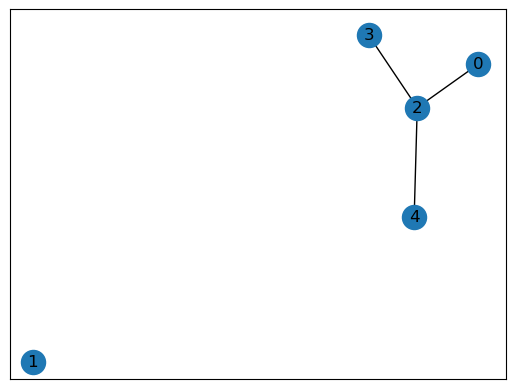

In [1]:
import networkx as nx
from freyrelab.nets.paths2 import Efficiency, ShortestDistances

G = nx.Graph()
G.add_nodes_from(range(5))
G.add_edges_from([(2, 4), (2, 3), (2, 0)])
# G = nx.relabel_nodes(G, {i: str(i) for i in G.nodes})

shortest_distances_G = ShortestDistances(G)
efficiency = Efficiency(G, shortest_distances_G)

for u, v in G.edges:
    print(f"efficiency for {u} and {v} is {efficiency.efficiency(u,v)}")

nx.draw_networkx(G)

In [11]:
G.nodes()

NodeView(('0', '1', '2', '3', '4'))

efficiency for 0 and 2 is 1.0
efficiency for 2 and 4 is 1.0
efficiency for 2 and 3 is 1.0


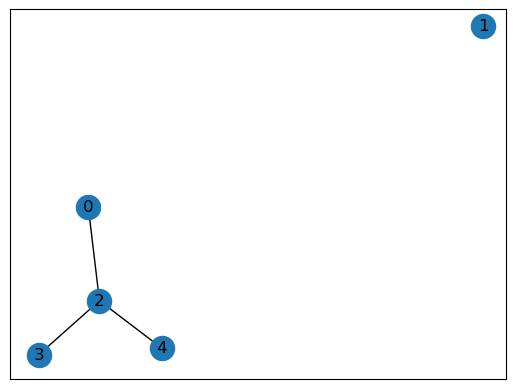

In [27]:
import networkx as nx
from freyrelab.nets.paths2 import Efficiency, ShortestDistances


G = nx.Graph()
G.add_nodes_from(range(5))
G.add_edges_from([(2, 4), (2, 3), (2, 0)])

G = nx.relabel_nodes(G, {i: str(i) for i in G.nodes})

shortest_distances_G = ShortestDistances(G)
efficiency = Efficiency(G, shortest_distances_G)

for u, v in G.edges:
    print(f"efficiency for {u} and {v} is {efficiency.efficiency(u,v)}")

nx.draw_networkx(G)

In [138]:
efficiency = Efficiency(G.to_undirected(), shortest_distances_G)
efficiency.global_efficiency

0.6833333333333333

    ¿Cómo usar local efficiency?

In [29]:
import networkx as nx
from freyrelab.nets.paths2 import Efficiency, ShortestDistances

G = nx.erdos_renyi_graph(10, 0.4)
G = nx.relabel_nodes(G, {i: str(i) for i in G.nodes})
shortest_distances_G = ShortestDistances(G)
efficiency = Efficiency(G, shortest_distances_G)
efficiency.local_efficiency

0.30000000000000004

## Otras

In [ ]:
'average_path_length',
 'center',
 'diameter',
 'eccentricity',

In [262]:
from freyrelab.nets.paths import Efficiency, ShortestDistances

G = nx.erdos_renyi_graph(10, 0.1)
shortest_distances_G = ShortestDistances(G)

In [263]:
# diameter
shortest_distances_G.diameter

4

In [274]:
# eccentricity
shortest_distances_G.eccentricity().values()

dict_values([1, 1, 3, 2, 4, 4, 3, 4, 0, 0])

In [266]:
# radius
shortest_distances_G.radius

0

In [268]:
# center
len(shortest_distances_G.center)

2

In [273]:
# periphery
len(shortest_distances_G.periphery)

3